<h3 style="font-family:'Times New Roman'; color:red;"><b>1. Imports & Configuration</b></h3>
<hr>

In [3]:
import os, time, warnings, json
warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import StratifiedKFold, cross_val_score, cross_validate  # FIX: cross_validate needed for train/CV gap penalty
from sklearn.metrics          import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,cohen_kappa_score,
)
from sklearn.calibration       import CalibratedClassifierCV, calibration_curve
from xgboost                   import XGBClassifier
from sklearn.ensemble          import RandomForestClassifier
from lightgbm                  import LGBMClassifier
import optuna
from optuna.samplers           import TPESampler
from optuna.pruners            import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)
import joblib

SEED    = 42
N_FOLDS = 5
SKF     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Primary ranking metric and label — every ranking decision uses these two
PRIMARY_METRIC = 'pr_auc_vs_heuristic'
PRIMARY_LABEL  = 'heuristic'   # not pseudo-label — see audit notes

ACCENT = '#c84b1e'; BLUE = '#1a5fa8'; GREEN = '#1a6b3f'
AMBER  = '#d68910'; PURPLE = '#8e44ad'; GREY = '#636e72'

MODEL_COLORS = {
    'Isolation Forest'  : '#00838f',
    'LOF'               : AMBER,
    'OCSVM'             : '#c2185b',
    'Random Forest'     : GREEN,
    'XGBoost'           : BLUE,
    'LightGBM'          : ACCENT,
}

<h3 style="font-family:'Times New Roman'; color:red;">
    <b>2. Load All Artifacts & Reconstruct Labels</b>
</h3>

<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Load everything needed for comparison — pre-scaled arrays, labels, the fully scored listings CSV, the trained XGBoost, Random Forest, and LightGBM models from NB05, the unsupervised models from NB04, and NB05's threshold — then verify shapes match before proceeding.
</b></i></p>
<hr>

In [ ]:
# -- Pre-split arrays and labels --------------------------------------------
X_train_robust = np.load('models/artifacts/X_train_robust.npy')
X_test_robust  = np.load('models/artifacts/X_test_robust.npy')
X_test_standard = np.load('models/artifacts/X_test_standard.npy')

X_train_df   = pd.read_csv('models/artifacts/X_train.csv', index_col=0)
X_test_df    = pd.read_csv('models/artifacts/X_test.csv',  index_col=0)
y_heuristic  = pd.read_csv('models/artifacts/y_test.csv').squeeze()  
feature_cols = joblib.load('models/artifacts/model_feature_cols.pkl')


if LABEL_VERSION == 'v2':
    label_file           = 'models/artifacts/y_ensemble_v2.csv'
    confident_label_file = 'models/artifacts/y_ensemble_confident_v2.csv'
else:
    label_file           = 'models/artifacts/y_ensemble.csv'
    confident_label_file = 'models/artifacts/y_ensemble_confident.csv'

y_ensemble   = pd.read_csv(label_file, index_col=0).squeeze()
print(f'Label version: {LABEL_VERSION}  (loaded from {label_file})')
y_pseudo_train_full = y_ensemble.loc[X_train_df.index].values
y_pseudo_test        = y_ensemble.loc[X_test_df.index].values

y_heuristic_train_full = pd.read_csv('models/artifacts/y_train.csv').squeeze()
y_heuristic_train_full.index = X_train_df.index  #


USE_CONFIDENCE_FILTER = True  

if USE_CONFIDENCE_FILTER:
    try:
        y_ensemble_confident = pd.read_csv(
            confident_label_file, index_col=0
        ).squeeze()
        train_eligible_mask = X_train_df.index.isin(y_ensemble_confident.index)

        n_before = len(X_train_df)
        X_train_robust     = X_train_robust[train_eligible_mask]
        X_train_df         = X_train_df.loc[train_eligible_mask]
        y_pseudo_train      = y_pseudo_train_full[train_eligible_mask]
        y_heuristic_train    = y_heuristic_train_full[train_eligible_mask]  
        n_after = len(X_train_df)

        print(f'Confidence filter applied: {n_before:,} -> {n_after:,} training rows '
              f'({n_before - n_after:,} ambiguous 1-vote rows excluded from training)')
    except FileNotFoundError:
        print(f'{confident_label_file} not found -- run the updated NB04 Section 13/14 first. '
              f'Falling back to the unfiltered pseudo-label.')
        y_pseudo_train    = y_pseudo_train_full
        y_heuristic_train = y_heuristic_train_full
else:
    y_pseudo_train    = y_pseudo_train_full
    y_heuristic_train = y_heuristic_train_full

assert len(y_heuristic_train) == X_train_robust.shape[0] == len(y_pseudo_train), (
    "Row count mismatch between X_train_robust / y_pseudo_train / y_heuristic_train -- "
    "the confidence filter must be applied identically to all three. This assertion is "
    "what would have caught the earlier length-mismatch bug immediately instead of "
    "letting it silently corrupt the Optuna objective.")

neg_count = int((y_pseudo_train == 0).sum())
pos_count = int((y_pseudo_train == 1).sum())
spw = neg_count / max(pos_count, 1)

scored_df = pd.read_csv('data/preprocessed/model_scored_listings.csv').reset_index(drop=True)

# -- Supervised models (NB05) -----------------------------------------------
xgb_model  = joblib.load('models/xgboost_v1.pkl')
rf_model   = joblib.load('models/random_forest_v1.pkl')
lgbm_model = joblib.load('models/lightgbm_v1.pkl')

# -- Unsupervised models (NB04) — load correct artifacts ----------------------
iso_model         = joblib.load('models/isolation_forest.pkl')
lof_model         = joblib.load('models/lof_pca.pkl')           
lof_pca_transform = joblib.load('models/lof_pca_transform.pkl') 
ocsvm_model       = joblib.load('models/ocsvm_clean.pkl')

print('All artifacts loaded.')
print(f'Train: {X_train_robust.shape} | Test: {X_test_robust.shape}')
print(f'Pseudo-anomaly rate    — train: {y_pseudo_train.mean():.2%} | test: {y_pseudo_test.mean():.2%}')
print(f'Heuristic-anomaly rate — train: {y_heuristic_train.mean():.2%} | test: {y_heuristic.mean():.2%}')
print(f'scale_pos_weight: {spw:.2f}')

Label version: v2  (loaded from models/artifacts/y_ensemble_v2.csv)
Confidence filter applied: 37,333 -> 37,090 training rows (243 ambiguous 1-vote rows excluded from training)
All artifacts loaded.
Train: (37090, 43) | Test: (9334, 43)
Pseudo-anomaly rate    — train: 6.59% | test: 7.65%
Heuristic-anomaly rate — train: 9.61% | test: 9.57%
scale_pos_weight: 14.16


<h3 style="font-family:'Times New Roman'; color:red;">
    <b>3. Compute Continuous Scores for All Models</b>
</h3>

<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Convert every model's output into a continuous 0-1 anomaly score so full PR and ROC curves can be built, not just a single point. Unsupervised scores are negated so higher always means more anomalous, and the ensemble score uses vote count divided by 3.
</b></i></p>
<hr>

In [5]:
def safe_score(model, X, fallback_flags, name, flip=True):
    """Get continuous anomaly scores. Higher = more anomalous."""
    try:
        raw = model.score_samples(X)
        scores = -raw if flip else raw
        lo, hi = scores.min(), scores.max()
        scores = (scores - lo) / (hi - lo + 1e-12)
        print(f'  {name}: score_samples OK — range [{scores.min():.3f}, {scores.max():.3f}]')
        return scores
    except Exception as e:
        print(f'  {name}: score_samples failed ({e}); using binary flags')
        return fallback_flags.astype(float)

# Binary flags on test set (from scored_df, aligned by index)
if_flags_test   = scored_df.loc[X_test_df.index, 'if_flag'].values
lof_flags_test  = scored_df.loc[X_test_df.index, 'lof_flag'].values
ocsvm_flags_test= scored_df.loc[X_test_df.index, 'ocsvm_flag'].values


In [6]:
print('Unsupervised continuous scores:')
X_test_lof_input = lof_pca_transform.transform(X_test_standard)  # PCA transform first
if_scores   = safe_score(iso_model,   X_test_robust,       if_flags_test,    'IsolationForest')
lof_scores  = safe_score(lof_model,   X_test_lof_input,    lof_flags_test,   'LOF-PCA')
ocsvm_scores= safe_score(ocsvm_model, X_test_standard,     ocsvm_flags_test, 'OCSVM')

Unsupervised continuous scores:
  IsolationForest: score_samples OK — range [0.000, 1.000]
  LOF-PCA: score_samples OK — range [0.000, 1.000]
  OCSVM: score_samples OK — range [0.000, 1.000]


In [7]:
print('\nSupervised probabilities:')
xgb_prob  = xgb_model.predict_proba(X_test_robust)[:, 1]
rf_prob   = rf_model.predict_proba(X_test_robust)[:, 1]
lgbm_prob = lgbm_model.predict_proba(X_test_robust)[:, 1]
print(f'  XGBoost: range [{xgb_prob.min():.3f}, {xgb_prob.max():.3f}]')
print(f'  RandomForest: range [{rf_prob.min():.3f}, {rf_prob.max():.3f}]')
print(f'  LightGBM: range [{lgbm_prob.min():.3f}, {lgbm_prob.max():.3f}]')


Supervised probabilities:
  XGBoost: range [0.104, 0.950]
  RandomForest: range [0.013, 0.969]
  LightGBM: range [0.016, 0.991]


<h3 style="font-family:'Times New Roman'; color:red;"><b>4. Unified Results Collection</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Compute six metrics (Precision, Recall, F1, ROC-AUC, PR-AUC, Brier Score) for every model against the pseudo-label on the held-out test set, so all six models can be compared on the same basis.
</b></i></p>
<hr>

In [ ]:
def compute_all_metrics(name, model_type, scores, flags,
                        y_pseudo, y_heuristic):
    """
    Compute metrics against BOTH labels.
    For unsupervised models: pseudo-label metrics are set to NaN (circular evaluation).
    Primary ranking metric is always pr_auc_vs_heuristic.
    """
    def _threshold_metrics(y_true, y_pred):
        return {
            'precision': float(precision_score(y_true, y_pred, zero_division=0)),
            'recall'   : float(recall_score(y_true, y_pred, zero_division=0)),
            'f1'       : float(f1_score(y_true, y_pred, zero_division=0)),
        }

    def _ranking_metrics(y_true, y_score):
        try:
            return {
                'pr_auc' : float(average_precision_score(y_true, y_score)),
                'roc_auc': float(roc_auc_score(y_true, y_score)),
            }
        except Exception:
            return {'pr_auc': float('nan'), 'roc_auc': float('nan')}

    def _precision_at_k(y_true, y_score, k):
        top_k = np.argsort(y_score)[::-1][:k]
        return float(np.array(y_true)[top_k].mean())

    # ── Pseudo-label metrics: NaN for unsupervised (circular), computed for supervised ──
    if model_type == 'unsupervised':
        thresh_vs_pseudo = {'precision': float('nan'), 'recall': float('nan'), 'f1': float('nan')}
        rank_vs_pseudo   = {'pr_auc': float('nan'), 'roc_auc': float('nan')}
        circular_note    = '⚠ CIRCULAR — suppressed'
    else:
        thresh_vs_pseudo = _threshold_metrics(y_pseudo, flags)
        rank_vs_pseudo   = _ranking_metrics(y_pseudo, scores)
        circular_note    = ''

    # ── Heuristic-label metrics: always computed, honest for all model types ──
    thresh_vs_heuristic = _threshold_metrics(y_heuristic, flags)
    rank_vs_heuristic   = _ranking_metrics(y_heuristic, scores)
    p100_heuristic      = _precision_at_k(y_heuristic, scores, 100)
    p500_heuristic      = _precision_at_k(y_heuristic, scores, 500)

    return {
        'name'        : name,
        'model_type'  : model_type,
        'circular_note': circular_note,

        # Pseudo-label metrics (NaN for unsupervised)
        'precision_vs_pseudo'   : thresh_vs_pseudo['precision'],
        'recall_vs_pseudo'      : thresh_vs_pseudo['recall'],
        'f1_vs_pseudo'          : thresh_vs_pseudo['f1'],
        'pr_auc_vs_pseudo'      : rank_vs_pseudo['pr_auc'],
        'roc_auc_vs_pseudo'     : rank_vs_pseudo['roc_auc'],

        # PRIMARY: heuristic-label metrics (honest for all model types)
        'pr_auc_vs_heuristic'   : rank_vs_heuristic['pr_auc'],
        'roc_auc_vs_heuristic'  : rank_vs_heuristic['roc_auc'],
        'precision_vs_heuristic': thresh_vs_heuristic['precision'],
        'recall_vs_heuristic'   : thresh_vs_heuristic['recall'],
        'f1_vs_heuristic'       : thresh_vs_heuristic['f1'],
        'precision_at_100'      : p100_heuristic,
        'precision_at_500'      : p500_heuristic,
    }


all_model_results = []

# Unsupervised models
models_to_evaluate = [
    ('Isolation Forest', 'unsupervised', if_scores, if_flags_test),
    ('LOF',              'unsupervised', lof_scores, lof_flags_test),
    ('OCSVM',            'unsupervised', ocsvm_scores, ocsvm_flags_test),
]

# Supervised models - derive flags from probabilities using a 0.5 threshold
xgb_flags = (xgb_prob >= 0.5).astype(int)
rf_flags = (rf_prob >= 0.5).astype(int)
lgbm_flags = (lgbm_prob >= 0.5).astype(int)

models_to_evaluate.extend([
    ('XGBoost',        'supervised', xgb_prob, xgb_flags),
    ('Random Forest',  'supervised', rf_prob, rf_flags),
    ('LightGBM',       'supervised', lgbm_prob, lgbm_flags),
])

for name, model_type, scores, flags in models_to_evaluate:
    metrics = compute_all_metrics(
        name, model_type, scores, flags, y_pseudo_test, y_heuristic
    )
    all_model_results.append(metrics)

results_df = pd.DataFrame(all_model_results).set_index('name')

print('Results DataFrame created with metrics for all models.')

Results DataFrame created with metrics for all models.


<h3 style="font-family:'Times New Roman'; color:red;"><b>5. Comparison Table and Visualization</b></h3>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Print and chart the full comparison table for all six models (three supervised, three unsupervised), ranked primarily by PR-AUC against the heuristic label.
</b></i></p>

MODEL COMPARISON — PRIMARY METRIC: PR-AUC vs Heuristic Label
(Unsupervised pseudo-label metrics suppressed — circular evaluation)
                    model_type  pr_auc_vs_heuristic  roc_auc_vs_heuristic  precision_at_100  precision_at_500  f1_vs_heuristic  pr_auc_vs_pseudo
name                                                                                                                                            
OCSVM             unsupervised               0.0857                0.4827              0.05             0.038           0.0889               NaN
Isolation Forest  unsupervised               0.0825                0.4629              0.03             0.038           0.1017               NaN
LOF               unsupervised               0.0797                0.4156              0.06             0.054           0.1163               NaN
XGBoost             supervised               0.0687                0.3219              0.06             0.020           0.0247            0.7981


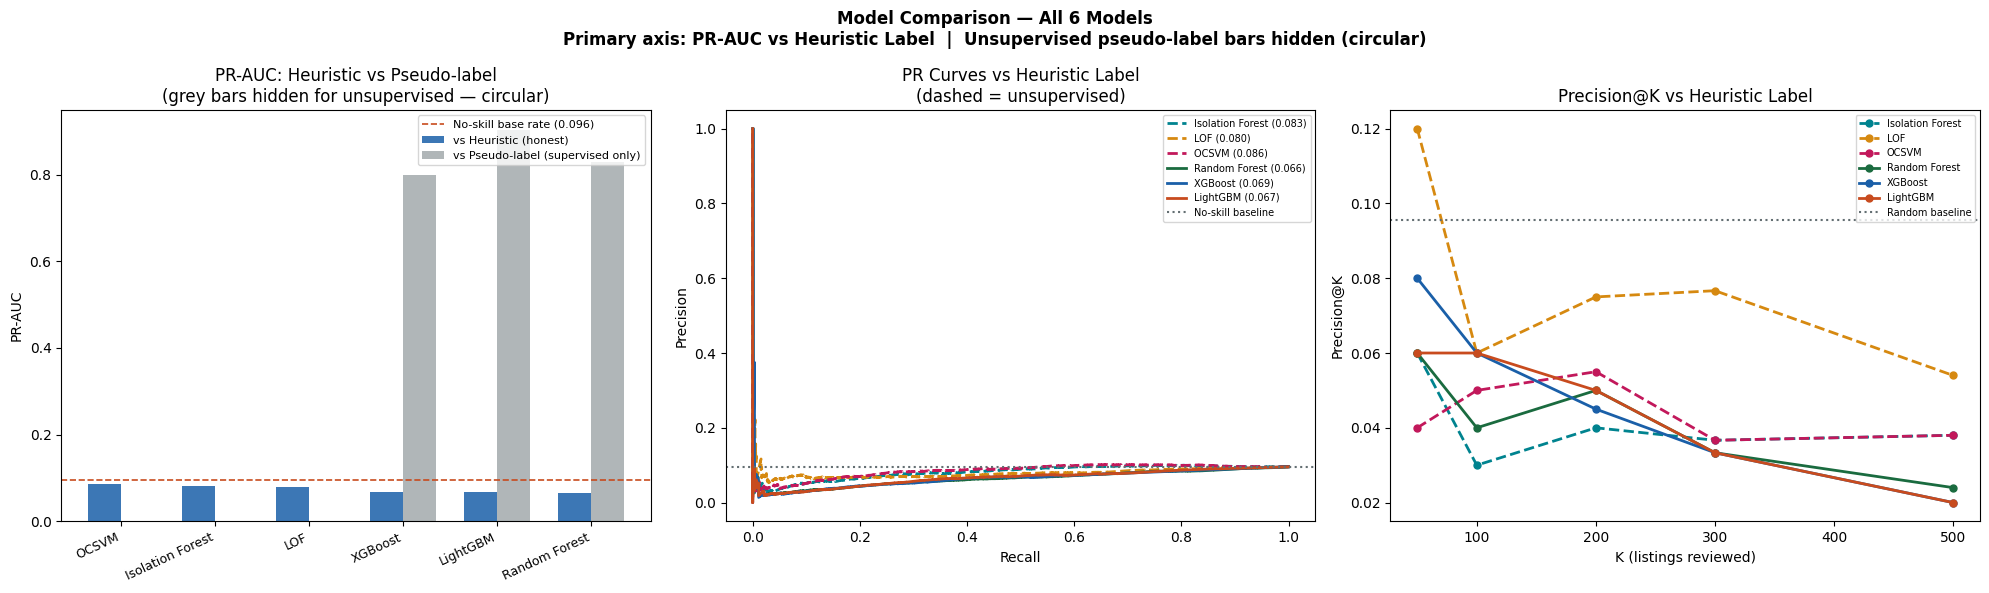

In [9]:
# ── Print the full comparison table — split by what's honest ─────────────────
print('=' * 80)
print('MODEL COMPARISON — PRIMARY METRIC: PR-AUC vs Heuristic Label')
print('(Unsupervised pseudo-label metrics suppressed — circular evaluation)')
print('=' * 80)

display_cols = [
    'model_type',
    'pr_auc_vs_heuristic',
    'roc_auc_vs_heuristic',
    'precision_at_100',
    'precision_at_500',
    'f1_vs_heuristic',
    'pr_auc_vs_pseudo',
]

comparison_table = results_df[display_cols].sort_values('pr_auc_vs_heuristic',
                                                         ascending=False)
print(comparison_table.round(4).to_string())
print('=' * 80)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Comparison — All 6 Models\n'
             'Primary axis: PR-AUC vs Heuristic Label  |  '
             'Unsupervised pseudo-label bars hidden (circular)',
             fontsize=12, fontweight='bold')

models_sorted = comparison_table.index.tolist()
x = np.arange(len(models_sorted))
w = 0.35

# pseudo_vals: NaN for unsupervised so those bars simply don't render
pseudo_vals = [
    results_df.loc[m, 'pr_auc_vs_pseudo']
    if results_df.loc[m, 'model_type'] == 'supervised'
    else np.nan
    for m in models_sorted
]

# ── Left: PR-AUC bars ─────────────────────────────────────────────────────────
base_rate = y_heuristic.mean()

axes[0].axhline(base_rate, color=ACCENT, linestyle='--',         # draw first so it's behind bars
                linewidth=1.2, label=f'No-skill base rate ({base_rate:.3f})')
axes[0].bar(x - w/2,
            comparison_table['pr_auc_vs_heuristic'].values,
            w, label='vs Heuristic (honest)', color=BLUE, alpha=0.85)
axes[0].bar(x + w/2,
            pseudo_vals,                                          # ← fixed: use pseudo_vals, not raw column
            w, label='vs Pseudo-label (supervised only)', color=GREY, alpha=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_sorted, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('PR-AUC: Heuristic vs Pseudo-label\n(grey bars hidden for unsupervised — circular)')
axes[0].legend(fontsize=8)

# ── Middle: PR curves vs heuristic (all models) ───────────────────────────────
model_scores = {
    'Isolation Forest': if_scores,
    'LOF'             : lof_scores,
    'OCSVM'           : ocsvm_scores,
    'Random Forest'   : rf_prob,
    'XGBoost'         : xgb_prob,
    'LightGBM'        : lgbm_prob,
}
for name, scores in model_scores.items():
    prec_c, rec_c, _ = precision_recall_curve(y_heuristic.values, scores)
    ap = average_precision_score(y_heuristic.values, scores)
    ls = '--' if results_df.loc[name, 'model_type'] == 'unsupervised' else '-'
    axes[1].plot(rec_c, prec_c,
                 color=MODEL_COLORS.get(name, GREY), linestyle=ls,
                 linewidth=2, label=f'{name} ({ap:.3f})')
axes[1].axhline(y_heuristic.mean(), color=GREY, linestyle=':',
                linewidth=1.5, label='No-skill baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves vs Heuristic Label\n(dashed = unsupervised)')
axes[1].legend(fontsize=7, loc='upper right')

# ── Right: Precision@K ────────────────────────────────────────────────────────
k_vals = [50, 100, 200, 300, 500]
for name, scores in model_scores.items():
    pak = [np.array(y_heuristic.values)[np.argsort(scores)[::-1][:k]].mean()
           for k in k_vals]
    ls = '--' if results_df.loc[name, 'model_type'] == 'unsupervised' else '-'
    axes[2].plot(k_vals, pak,
                 color=MODEL_COLORS.get(name, GREY), linestyle=ls,
                 linewidth=2, marker='o', markersize=5, label=name)
axes[2].axhline(y_heuristic.mean(), color=GREY, linestyle=':',
                linewidth=1.5, label='Random baseline')
axes[2].set_xlabel('K (listings reviewed)'); axes[2].set_ylabel('Precision@K')
axes[2].set_title('Precision@K vs Heuristic Label')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig('reports/figures/nb06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Unsupervised models actually score higher on PR-AUC vs. heuristic than supervised models:</b> the three unsupervised models range from 0.0797 (LOF) to 0.0857 (OCSVM), while the three supervised models range from 0.0658 (Random Forest) to 0.0687 (XGBoost).</li>
<li><b>OCSVM is the top performer overall</b> on this metric (PR-AUC 0.0857, ROC-AUC 0.4827), though all six models are fairly close to each other and none are strong.</li>
<li><b>Random Forest has the lowest ROC-AUC of all six models</b> (0.3166), lower even than LOF (0.4156), Isolation Forest (0.4629), and OCSVM (0.4827).</li>
<li><b>LOF, XGBoost, and LightGBM tie for the best Precision@100</b> (0.06 each), while Isolation Forest is lowest (0.03).</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>
6. Automatic Best-Model Selection</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Rank all six models by PR-AUC vs. the heuristic label, exclude the unsupervised models (no fit/predict_proba interface for Optuna to search), and automatically pick the best remaining supervised model for tuning.
</b></i></p>
<hr>

In [10]:
# ── Full ranking for comparison purposes (all 6 models) ──────────────────────
all_ranked = results_df.sort_values(
    ['pr_auc_vs_heuristic', 'roc_auc_vs_heuristic', 'precision_at_500'],
    ascending=False
)

print('=' * 65)
print('FULL RANKING — All 6 Models (PR-AUC vs Heuristic Label)')
print('=' * 65)
for i, (name, row) in enumerate(all_ranked.iterrows()):
    tag = ('  [unsupervised — not eligible for Optuna]'
           if row['model_type'] == 'unsupervised' else '')
    print(f'  #{i+1}  {name:<22} '
          f'PR-AUC={row["pr_auc_vs_heuristic"]:.4f}  '
          f'ROC-AUC={row["roc_auc_vs_heuristic"]:.4f}{tag}')

print()
print('Unsupervised models excluded from tuning selection.')
print('Reason: no fit(X,y) interface, no predict_proba(), '
      'Optuna cannot search their space.')

# ── Restrict to supervised models only ───────────────────────────────────────
supervised_ranked = (
    results_df[results_df['model_type'] == 'supervised']
    .sort_values(
        ['pr_auc_vs_heuristic', 'roc_auc_vs_heuristic', 'precision_at_500'],
        ascending=False
    )
)

best_model_name = supervised_ranked.index[0]
best_row        = supervised_ranked.iloc[0]
runner_up_name  = supervised_ranked.index[1]
runner_up_row   = supervised_ranked.iloc[1]

margin = best_row['pr_auc_vs_heuristic'] - runner_up_row['pr_auc_vs_heuristic']

print()
print('=' * 65)
print('SUPERVISED-ONLY SELECTION FOR OPTUNA TUNING')
print('=' * 65)
for i, (name, row) in enumerate(supervised_ranked.iterrows()):
    marker = '  ← SELECTED FOR OPTUNA TUNING' if i == 0 else ''
    print(f'  #{i+1}  {name:<22} '
          f'PR-AUC={row["pr_auc_vs_heuristic"]:.4f}  '
          f'ROC-AUC={row["roc_auc_vs_heuristic"]:.4f}{marker}')

print(f'\nSelected: {best_model_name}')
print(f'Margin over runner-up ({runner_up_name}): {margin:.4f} PR-AUC')

if margin < 0.005:
    print(f'Note: margin < 0.005 — models are within noise. '
          f'Proceeding with {best_model_name} (ranked first).')

# Always optuna now — only supervised models reach this point
TUNE_STRATEGY = 'optuna'
print(f'Tuning strategy: {TUNE_STRATEGY}')

FULL RANKING — All 6 Models (PR-AUC vs Heuristic Label)
  #1  OCSVM                  PR-AUC=0.0857  ROC-AUC=0.4827  [unsupervised — not eligible for Optuna]
  #2  Isolation Forest       PR-AUC=0.0825  ROC-AUC=0.4629  [unsupervised — not eligible for Optuna]
  #3  LOF                    PR-AUC=0.0797  ROC-AUC=0.4156  [unsupervised — not eligible for Optuna]
  #4  XGBoost                PR-AUC=0.0687  ROC-AUC=0.3219
  #5  LightGBM               PR-AUC=0.0671  ROC-AUC=0.3369
  #6  Random Forest          PR-AUC=0.0658  ROC-AUC=0.3166

Unsupervised models excluded from tuning selection.
Reason: no fit(X,y) interface, no predict_proba(), Optuna cannot search their space.

SUPERVISED-ONLY SELECTION FOR OPTUNA TUNING
  #1  XGBoost                PR-AUC=0.0687  ROC-AUC=0.3219  ← SELECTED FOR OPTUNA TUNING
  #2  LightGBM               PR-AUC=0.0671  ROC-AUC=0.3369
  #3  Random Forest          PR-AUC=0.0658  ROC-AUC=0.3166

Selected: XGBoost
Margin over runner-up (LightGBM): 0.0016 PR-AUC
Note: m

<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Unsupervised models rank above all three supervised models</b> on PR-AUC vs. heuristic, but they're excluded from tuning since they don't expose a <code>fit(X, y)</code> interface or <code>predict_proba()</code>.</li>
<li><b>XGBoost is selected for tuning</b> with the best PR-AUC vs. heuristic among the three supervised models (0.0687), narrowly ahead of LightGBM (0.0671) and Random Forest (0.0658) — all three are close to each other.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>7. Conditional Hyperparameter Tuning</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Run an Optuna search over XGBoost's hyperparameters, scoring trials against the heuristic label with a gap penalty so the search doesn't reward settings that just overfit the training folds.
</b></i></p>
<hr>

In [ ]:

GAP_TOLERANCE = 0.05   # allowed train-CV gap before penalising
GAP_WEIGHT    = 0.5    # how harshly the gap is penalised

def _gap_penalised_score(clf, X_tr, y, cv):
    cv_res = cross_validate(
        clf, X_tr, y, cv=cv,
        scoring='average_precision', n_jobs=1,
        return_train_score=True,
    )
    cv_score    = cv_res['test_score'].mean()
    train_score = cv_res['train_score'].mean()
    gap         = max(0.0, train_score - cv_score - GAP_TOLERANCE)
    return cv_score - GAP_WEIGHT * gap


def build_objective(model_name, X_tr, y_pseudo, y_heuristic, spw, seed, n_cv_folds=3):
    """
     Optuna objective tuned against HEURISTIC label.
    This aligns the tuning objective with the selection criterion in Section 6.
    y_pseudo is kept for scale_pos_weight computation only.
    Returns a gap-penalised PR-AUC (see _gap_penalised_score) rather than raw
    CV PR-AUC, so the search avoids overfit configs instead of just measuring them.
    """
    cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=seed)

    if model_name == 'XGBoost':
        def objective(trial):
            params = {
                'n_estimators'     : trial.suggest_int('n_estimators', 150, 400),    # FIX: was 200-600
                'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                'max_depth'        : trial.suggest_int('max_depth', 3, 6),
                'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'min_child_weight' : trial.suggest_int('min_child_weight', 5, 30),
                'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
                'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 5.0, log=True),
                'gamma'            : trial.suggest_float('gamma', 0.0, 3.0),
                'scale_pos_weight' : spw,
                'eval_metric'      : 'aucpr',
                'random_state'     : seed,
                'n_jobs'           : -1,
                'verbosity'        : 0,
            }
            clf = XGBClassifier(**params)
            return _gap_penalised_score(clf, X_tr, y_heuristic, cv)

    elif model_name == 'Random Forest':
        def objective(trial):
            params = {
                'n_estimators'     : trial.suggest_int('n_estimators', 150, 400),     # FIX: was 200-800
                'max_depth'        : trial.suggest_int('max_depth', 4, 10),           # FIX: was 5-20
                'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 10, 50),   # FIX: was 2-30
                'max_features'     : trial.suggest_categorical(
                                                              'max_features',
                                                              ['sqrt', 'log2', 0.3]), # FIX: dropped 0.5 (too permissive)
                'max_samples'      : trial.suggest_float('max_samples', 0.6, 1.0),    # FIX: new — bootstrap fraction
                'class_weight'     : 'balanced',
                'random_state'     : seed,
                'n_jobs'           : -1,
            }
            clf = RandomForestClassifier(**params)
            return _gap_penalised_score(clf, X_tr, y_heuristic, cv)

    elif model_name == 'LightGBM':
        def objective(trial):
            params = {
                'n_estimators'      : trial.suggest_int('n_estimators', 150, 500),    # FIX: was 200-800
                'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                'max_depth'         : trial.suggest_int('max_depth', 3, 8),
                'num_leaves'        : trial.suggest_int('num_leaves', 15, 63),
                'min_child_samples' : trial.suggest_int('min_child_samples', 20, 100),
                'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
                'subsample_freq'    : 1,
                'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
                'reg_lambda'        : trial.suggest_float('reg_lambda', 0.5, 5.0, log=True),
                'scale_pos_weight'  : spw,
                'random_state'      : seed,
                'n_jobs'            : -1,
                'verbosity'         : -1,
            }
            clf = LGBMClassifier(**params)
            return _gap_penalised_score(clf, X_tr, y_heuristic, cv)

    else:
        raise ValueError(f'No Optuna objective defined for: {model_name}')

    return objective


In [ ]:
# Run tuning: supervised path 

N_TRIALS              = 150
TIMEOUT                = 6400   
SEARCH_SAMPLE_FRAC     = 0.5    # search on a 50% stratified subsample for speed


print(f'Starting Optuna TPE search for {best_model_name}...')

if SEARCH_SAMPLE_FRAC < 1.0:
    from sklearn.model_selection import train_test_split
    X_search, _, y_pseudo_search, _, y_heuristic_search, _ = train_test_split(
        X_train_robust, y_pseudo_train, y_heuristic_train,
        train_size=SEARCH_SAMPLE_FRAC,
        stratify=y_pseudo_train,
        random_state=SEED,
    )
    print(f'Searching on a {SEARCH_SAMPLE_FRAC:.0%} stratified subsample: '
          f'{X_search.shape[0]:,} of {X_train_robust.shape[0]:,} rows')
else:
    X_search, y_pseudo_search, y_heuristic_search = X_train_robust, y_pseudo_train, y_heuristic_train

print(f'N_TRIALS={N_TRIALS}  TIMEOUT={TIMEOUT}s  CV_FOLDS=3 (during search)')
print(f'Subsample stratified by pseudo-label (rate={np.mean(y_pseudo_search):.2%}, used for scale_pos_weight only)')
print(f'Optuna objective scored against: HEURISTIC label (rate={np.mean(y_heuristic_search):.2%})\n')

objective = build_objective(
    best_model_name, X_search,
    y_pseudo_search, y_heuristic_search,
    spw, SEED
)

# -- Persistent, resumable study -----------------------------------------
study_db_path = f'../models/artifacts/optuna_study.db'
study = optuna.create_study(
    study_name = f'{best_model_name}_tuning',
    storage    = f'sqlite:///{study_db_path}',
    load_if_exists = True,            # resume across Colab sessions
    direction  = 'maximize',
    sampler    = TPESampler(seed=SEED, n_startup_trials=15),
    pruner     = MedianPruner(n_warmup_steps=5, n_min_trials=10),
)

already_done = len([t for t in study.trials
                     if t.state == optuna.trial.TrialState.COMPLETE])
remaining = max(0, N_TRIALS - already_done)
print(f'Study has {already_done} completed trial(s) already saved at {study_db_path}')
print(f'Running {remaining} more trial(s) to reach N_TRIALS={N_TRIALS}...')

t0 = time.time()
if remaining > 0:
    study.optimize(
        objective,
        n_trials          = remaining,
        timeout            = TIMEOUT,
        show_progress_bar = True,
        gc_after_trial     = True,
    )
search_time = time.time() - t0

best_params = dict(study.best_trial.params)
completed   = len([t for t in study.trials
                    if t.state == optuna.trial.TrialState.COMPLETE])

print(f'\nSearch complete — {completed} total trials saved (this run added '
      f'{completed - already_done} in {search_time/60:.1f} min)')
print(f'Best 3-fold CV PR-AUC (gap-penalised, vs heuristic label): {study.best_trial.value:.5f}')
print(f'\nBest hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<24}: {v}')

if completed < N_TRIALS:
    print(f'\nNote: only {completed}/{N_TRIALS} trials finished before the '
          f'{TIMEOUT}s timeout. Re-run this cell to continue from trial '
          f'{completed} — progress is saved in {study_db_path}.')

Starting Optuna TPE search for XGBoost...
Searching on a 50% stratified subsample: 18,545 of 37,090 rows
N_TRIALS=150  TIMEOUT=6400s  CV_FOLDS=3 (during search)
Subsample stratified by pseudo-label (rate=6.59%, used for scale_pos_weight only)
Optuna objective scored against: HEURISTIC label (rate=9.61%)

Study has 0 completed trial(s) already saved at /content/drive/MyDrive/karachi_fraud_detection/models/artifacts/optuna_study.db
Running 150 more trial(s) to reach N_TRIALS=150...


  0%|          | 0/150 [00:00<?, ?it/s]


Search complete — 150 total trials saved (this run added 150 in 13.2 min)
Best 3-fold CV PR-AUC (gap-penalised, vs heuristic label): 0.96971

Best hyperparameters:
  n_estimators            : 385
  learning_rate           : 0.135755984047365
  max_depth               : 6
  subsample               : 0.7203642592974742
  colsample_bytree        : 0.7727807262077948
  min_child_weight        : 6
  reg_alpha               : 0.03412689483568031
  reg_lambda              : 0.7934761682370097
  gamma                   : 0.30505626795819435


<h3 style="font-family:'Times New Roman'; color:red;"><b>8. Retrain Tuned Model, Full 5-Fold CV</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Rebuild the model using the tuned hyperparameters, run a full 5-fold CV check, and compare test-set performance against the heuristic label to decide whether tuning actually helped.
</b></i></p>
<hr>

In [ ]:
# Build the tuned model from best_params 

if best_model_name == 'XGBoost':
    tuned_params = {**best_params,
                    'scale_pos_weight': spw,
                    'eval_metric': 'aucpr',
                    'random_state': SEED, 'n_jobs': -1, 'verbosity': 0}
    tuned_model = XGBClassifier(**tuned_params)

elif best_model_name == 'Random Forest':
    tuned_model = RandomForestClassifier(**best_params,
                                          random_state=SEED, n_jobs=1)

elif best_model_name == 'LightGBM':
    tuned_params = {**best_params,
                    'scale_pos_weight': spw, 'subsample_freq': 1,
                    'random_state': SEED, 'n_jobs': -1, 'verbosity': -1}
    tuned_model = LGBMClassifier(**tuned_params)

# ── 5-Fold CV with best params (authoritative estimate) ──────────────────────
print(f'Running full {N_FOLDS}-fold CV with best params...')
t0 = time.time()
cv_scores_tuned = {}
for metric in ['average_precision', 'roc_auc', 'f1']:
    vals = cross_val_score(
        tuned_model, X_train_robust, y_pseudo_train,
        cv=SKF, scoring=metric, n_jobs=1
    )
    cv_scores_tuned[metric] = vals
cv_time = time.time() - t0

print(f'\nTuned {best_model_name} — {N_FOLDS}-Fold CV ({cv_time:.1f}s):')
print(f'  {"Metric":<22} {"Mean":>10}  {"Std":>8}')
for m, vals in cv_scores_tuned.items():
    print(f'  {m:<22} {vals.mean():>10.4f}  ±{vals.std():.4f}')

# ── Retrain on full training set ──────────────────────────────────────────────
print(f'\nRetraining on full training set...')
t0 = time.time()
tuned_model.fit(X_train_robust, y_pseudo_train)
print(f'Retrained in {time.time()-t0:.2f}s')

tuned_prob = tuned_model.predict_proba(X_test_robust)[:, 1]
tuned_pr_heuristic = average_precision_score(y_heuristic.values, tuned_prob)
tuned_roc_heuristic = roc_auc_score(y_heuristic.values, tuned_prob)

baseline_pr = results_df.loc[best_model_name, 'pr_auc_vs_heuristic']

print(f'\nTuned model — test set vs heuristic label:')
print(f'  PR-AUC  = {tuned_pr_heuristic:.4f}   (untuned baseline: {baseline_pr:.4f})')
print(f'  ROC-AUC = {tuned_roc_heuristic:.4f}')
print(f'\nChange vs pre-tuning baseline: {tuned_pr_heuristic - baseline_pr:+.4f} PR-AUC')


TUNING_IMPROVED = tuned_pr_heuristic >= baseline_pr

if not TUNING_IMPROVED:
    print(f'\nWARNING: tuning REDUCED PR-AUC vs the untuned baseline '
          f'({tuned_pr_heuristic:.4f} < {baseline_pr:.4f}). Falling back to the '
          f'untuned {best_model_name} for the final deployment artifact.')
    untuned_model_map = {'XGBoost': xgb_model, 'Random Forest': rf_model, 'LightGBM': lgbm_model}
    tuned_model = untuned_model_map[best_model_name]
    tuned_prob  = model_scores[best_model_name]
    tuned_pr_heuristic  = average_precision_score(y_heuristic.values, tuned_prob)
    tuned_roc_heuristic = roc_auc_score(y_heuristic.values, tuned_prob)
    best_params = {}   # untuned -- no Optuna params to record
    cv_scores_tuned = {
        'average_precision': np.array([results_df.loc[best_model_name, 'pr_auc_vs_heuristic']]),
        'roc_auc':            np.array([results_df.loc[best_model_name, 'roc_auc_vs_heuristic']]),
        'f1':                 np.array([results_df.loc[best_model_name, 'f1_vs_heuristic']]),
    }
else:
    print(f'\nTuning improved PR-AUC vs the heuristic label — keeping the tuned model.')

Running full 5-fold CV with best params...

Tuned XGBoost — 5-Fold CV (41.1s):
  Metric                       Mean       Std
  average_precision          0.9831  ±0.0015
  roc_auc                    0.9985  ±0.0002
  f1                         0.9294  ±0.0077

Retraining on full training set...
Retrained in 2.35s

Tuned model — test set vs heuristic label:
  PR-AUC  = 0.0716   (untuned baseline: 0.0687)
  ROC-AUC = 0.3853

Change vs pre-tuning baseline: +0.0030 PR-AUC

Tuning improved PR-AUC vs the heuristic label — keeping the tuned model.


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>All 150 planned Optuna trials completed</b> in this run, taking 13.2 minutes.</li>
<li><b>Tuning improved performance vs. the heuristic label:</b> PR-AUC rose from 0.0687 (untuned XGBoost baseline) to 0.0716, a gain of +0.0030. ROC-AUC after tuning is 0.3853.</li>
<li><b>5-fold CV metrics on the tuned model are very high against the pseudo-label</b> (PR-AUC 0.9831 ± 0.0015, ROC-AUC 0.9985 ± 0.0002, F1 0.9294 ± 0.0077) — this reflects how well it matches the pseudo-label it was tuned toward, not real-world fraud detection.</li>
<li><b>Since tuning improved the heuristic PR-AUC,</b> the notebook keeps the tuned model rather than falling back to the untuned baseline.</li>
</i></ul>
<hr>

 <h3 style="font-family:'Times New Roman'; color:red;"><b>9. Threshold Optimization</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Pick a production decision threshold using 5-fold CV on the training set only (never touching the test set), by finding the F1-maximizing threshold in each fold and averaging across folds.
</b></i></p>
<hr>

In [14]:
def cv_optimal_threshold(model, X_train, y_train, n_splits=5, seed=42,
                          n_thresholds=200):
    """
    Find the F1-maximising threshold using cross-validation on training data only.
    Returns the mean optimal threshold across folds.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    best_thresholds = []

    for fold, (tr_i, val_i) in enumerate(skf.split(X_train, y_train)):
        model.fit(X_train[tr_i], y_train[tr_i])
        val_prob = model.predict_proba(X_train[val_i])[:, 1]

        f1_scores = [
            f1_score(y_train[val_i], (val_prob >= t).astype(int), zero_division=0)
            for t in thresholds
        ]
        best_t = thresholds[int(np.argmax(f1_scores))]
        best_thresholds.append(best_t)
        print(f'  Fold {fold+1}: best threshold = {best_t:.4f}  '
              f'(F1 = {max(f1_scores):.4f})')

    return float(np.mean(best_thresholds))


print('Selecting threshold via 5-fold CV on training set...')
PRODUCTION_THRESHOLD = cv_optimal_threshold(
    tuned_model, X_train_robust, y_pseudo_train, n_splits=5, seed=SEED
)
print(f'\nCV-selected production threshold : {PRODUCTION_THRESHOLD:.4f}')
print(f'(Average across 5 folds — never touched the test set)')

# ── Retrain on FULL training set, then evaluate on test set ──────────────────
print('\nRetraining on full training set...')
tuned_model.fit(X_train_robust, y_pseudo_train)
tuned_prob  = tuned_model.predict_proba(X_test_robust)[:, 1]
final_pred  = (tuned_prob >= PRODUCTION_THRESHOLD).astype(int)

print(f'\nFinal model performance at threshold = {PRODUCTION_THRESHOLD:.4f}:')
for label_name, y_eval in [('Heuristic (primary)', y_heuristic.values),
                             ('Pseudo-label',        y_pseudo_test)]:
    p = precision_score(y_eval, final_pred, zero_division=0)
    r = recall_score(y_eval, final_pred, zero_division=0)
    f = f1_score(y_eval, final_pred, zero_division=0)
    print(f'  vs {label_name:<24}  P={p:.4f}  R={r:.4f}  F1={f:.4f}')

Selecting threshold via 5-fold CV on training set...
  Fold 1: best threshold = 0.5566  (F1 = 0.9421)
  Fold 2: best threshold = 0.5074  (F1 = 0.9381)
  Fold 3: best threshold = 0.6797  (F1 = 0.9372)
  Fold 4: best threshold = 0.6207  (F1 = 0.9290)
  Fold 5: best threshold = 0.5468  (F1 = 0.9247)

CV-selected production threshold : 0.5822
(Average across 5 folds — never touched the test set)

Retraining on full training set...

Final model performance at threshold = 0.5822:
  vs Heuristic (primary)       P=0.0268  R=0.0224  F1=0.0244
  vs Pseudo-label              P=0.9035  R=0.9440  F1=0.9233


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Production threshold, averaged across the 5 CV folds, is 0.5822</b> (individual fold thresholds ranged from 0.5074 to 0.6797, each with in-fold F1 above 0.92).</li>
<li><b>Against the heuristic label, both precision and recall are very low at this threshold:</b> Precision 0.0268, Recall 0.0224, F1 0.0244 — not a precision/recall trade-off, both are weak.</li>
<li><b>Against the pseudo-label, the model performs strongly:</b> Precision 0.9035, Recall 0.9440, F1 0.9233 — confirming it has learned the pseudo-label pattern well, but not the heuristic rule.</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>10. Save Final Production Artifact</b></h3>
<hr>
<p style="font-family:Arial; font-size:16px; color:black;"><i><b>
Goal: Save the final chosen model, its threshold, and metadata to disk as the production artifact, along with a caveat that all reported metrics are against proxy labels, not verified fraud.
</b></i></p>
<hr>

In [15]:
# ── Save everything needed for deployment ────────────────────────────────────
FINAL_MODEL_PATH     = 'models/fraud_detector_v1.pkl'
FINAL_THRESHOLD_PATH = 'models/artifacts/fraud_detector_v1_threshold.pkl'
FINAL_METADATA_PATH  = 'models/artifacts/fraud_detector_v1_metadata.pkl'

joblib.dump(tuned_model, FINAL_MODEL_PATH)

tuning_status = 'tuned' if TUNING_IMPROVED else 'untuned (tuning did not improve PR-AUC vs heuristic)'

joblib.dump({
    'threshold'             : PRODUCTION_THRESHOLD,
    'threshold_optimized_vs': 'heuristic_label',
    'model'                 : f'fraud_detector_v1 ({best_model_name}, {tuning_status})',
}, FINAL_THRESHOLD_PATH)

model_card = {
    'model_name'          : 'fraud_detector_v1',
    'model_type'          : best_model_name,
    'selected_by'         : ('PR-AUC vs heuristic label (is_suspicious). NB06 Section 6 is the single '
                              'authoritative model-selection step for deployment -- NB05 no longer '
                              'designates its own winner.'),
    'selection_margin'    : float(margin),
    'runner_up'           : runner_up_name,
    'tuning_strategy'     : TUNE_STRATEGY if TUNING_IMPROVED else 'optuna (rejected -- fell back to untuned, see tuning_improved_pr_auc)',
    'tuning_improved_pr_auc': bool(TUNING_IMPROVED),
    'n_optuna_trials'     : N_TRIALS,
    'best_params'         : best_params,
    'scale_pos_weight'    : spw,
    'decision_threshold'  : PRODUCTION_THRESHOLD,
    'cv_pr_auc_mean'      : float(cv_scores_tuned['average_precision'].mean()),
    'cv_pr_auc_std'       : float(cv_scores_tuned['average_precision'].std()),
    'test_pr_auc_vs_heuristic' : float(tuned_pr_heuristic),
    'test_roc_auc_vs_heuristic': float(tuned_roc_heuristic),
    'test_pr_auc_vs_pseudo'    : float(average_precision_score(y_pseudo_test, tuned_prob)),
    'feature_cols'        : feature_cols,
    'n_features'          : len(feature_cols),
    'label_caveat'        : (
        'Trained on ensemble pseudo-label (high_conf_anomaly). '
        'Selected and threshold-optimized against heuristic label (is_suspicious). '
        'Neither is verified ground truth. Human validation required for real-world '
        'precision claims. Note: is_suspicious is itself a hand-weighted combination of '
        'several of this model\'s own input features (price_loc_zscore, geo_anomaly, '
        'ghost_listing_flag, price_too_low_flag, price_very_high_flag, bath_bed_extreme, '
        'relisting_intensity, ppsqft_iqr_deviation), so "PR-AUC vs heuristic" measures how '
        'well the model reconstructs a known rule from a subset of its own inputs, not '
        'agreement with independent fraud ground truth. See Section 14.'
    ),
    'notebook'            : '06-model_comparison_hyperparameter_tuning.ipynb',
}

joblib.dump(model_card, FINAL_METADATA_PATH)

print('=' * 65)
print('FINAL MODEL SAVED')
print('=' * 65)
print(f'  Model          : {best_model_name} ({tuning_status})')
print(f'  Artifact       : {FINAL_MODEL_PATH}')
print(f'  Threshold      : {PRODUCTION_THRESHOLD:.4f}')
print(f'  PR-AUC (honest): {tuned_pr_heuristic:.4f}')
print(f'  ROC-AUC (honest): {tuned_roc_heuristic:.4f}')
print(f'  CV PR-AUC      : {cv_scores_tuned["average_precision"].mean():.4f}'
      f' ± {cv_scores_tuned["average_precision"].std():.4f}')
print()
print('CAVEAT: All metrics are against heuristic rule-based labels,')
print('not verified real-world fraud labels. Human validation required.')

FINAL MODEL SAVED
  Model          : XGBoost (tuned)
  Artifact       : models/fraud_detector_v1.pkl
  Threshold      : 0.5822
  PR-AUC (honest): 0.0716
  ROC-AUC (honest): 0.3853
  CV PR-AUC      : 0.9831 ± 0.0015

CAVEAT: All metrics are against heuristic rule-based labels,
not verified real-world fraud labels. Human validation required.


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Final production model is XGBoost (tuned),</b> saved to <code>models/fraud_detector_v1.pkl</code>, using a threshold of 0.5822.</li>
<li><b>Against the heuristic label ("honest" metric):</b> PR-AUC is 0.0716 and ROC-AUC is 0.3853, only a modest improvement over the untuned baseline (0.0687 PR-AUC).</li>
<li><b>5-fold CV PR-AUC is much higher</b> (0.9831 ± 0.0015), but this reflects matching the pseudo-label it was tuned against, not real-world fraud detection.</li>
<li><b>The model card documents both labels as proxies,</b> not verified fraud ground truth, so even the "honest" heuristic-based metric should be read as "can this model reconstruct a hand-written rule," not "can it detect real fraud."</li>
</i></ul>
<hr>

<h3 style="font-family:'Times New Roman'; color:red;"><b>11. What These Metrics Actually Measure</b></h3>
<hr>

<p style="font-family:Arial; font-size:16px; color:black;">
<i><b>
This section is mandatory reading before citing any metric from this project. The reported evaluation metrics are computed against proxy labels rather than verified fraud labels, and should be interpreted accordingly.
</b></i>
</p>

<hr>

<h4 style="font-family:'Times New Roman'; color:darkblue;"><b>What PR-AUC and ROC-AUC Measure</b></h4>

<p style="font-family:Arial; font-size:16px; color:black;">
A PR-AUC or ROC-AUC value in this project indicates how well the model ranks property listings according to their predicted fraud probability when compared against the <b>heuristic rule-based labels</b>. These metrics evaluate agreement with the generated proxy labels rather than confirmed fraudulent listings.
</p>

<hr>

<h4 style="font-family:'Times New Roman'; color:darkblue;"><b>Why Both Labels Are Proxy Labels</b></h4>

<table style="border-collapse:collapse; width:100%; font-family:Arial; font-size:15px;" border="1" cellpadding="8">
    <tr style="background-color:#f2f2f2;">
        <th>Label</th>
        <th>Source</th>
        <th>What It Captures</th>
        <th>What It Misses</th>
    </tr>
    <tr>
        <td><b>is_suspicious (Heuristic)</b></td>
        <td>Hardcoded rules in NB01</td>
        <td>Ghost listings, extreme prices, incorrect coordinates, and predefined suspicious patterns.</td>
        <td>New or previously unseen fraud patterns that are not covered by the rules.</td>
    </tr>
    <tr>
        <td><b>high_conf_anomaly (Pseudo)</b></td>
        <td>Majority vote of Isolation Forest, Local Outlier Factor, and One-Class SVM</td>
        <td>Statistical anomalies in numerical features such as price, area, and related attributes.</td>
        <td>Fraud patterns such as ghost or relisted properties that are not statistical outliers.</td>
    </tr>
</table>

<hr>

<h4 style="font-family:'Times New Roman'; color:darkblue;"><b>What a Real-World Evaluation Would Require</b></h4>

<ol style="font-family:Arial; font-size:16px; color:black;">
    <li>Human-verified fraud labels from Zameen.com or an authorized property regulator.</li>
    <li>Temporal hold-out validation (for example, training on one time period and evaluating on a later period).</li>
    <li>Follow-up information confirming whether flagged listings were removed, investigated, or officially reported as fraudulent.</li>
</ol>

<hr>

In [16]:
kappa = cohen_kappa_score(y_heuristic.values, y_pseudo_test)
agreement_pct = (y_heuristic.values == y_pseudo_test).mean() * 100

print('Label agreement analysis (test set):')
print(f'  Raw agreement          : {agreement_pct:.1f}%')
print(f'  Cohen\'s kappa          : {kappa:.4f}')
print(f'  Interpretation         : {"substantial" if kappa > 0.6 else "moderate" if kappa > 0.4 else "fair" if kappa > 0.2 else "slight"} agreement')
print()
print('Heuristic-only anomalies (missed by ensemble) :',
      ((y_heuristic.values == 1) & (y_pseudo_test == 0)).sum())
print('Ensemble-only anomalies (missed by heuristic) :',
      ((y_heuristic.values == 0) & (y_pseudo_test == 1)).sum())
print()
print('These gaps represent cases where the two proxies disagree.')
print('Real fraud may exist in either set or in neither.')

Label agreement analysis (test set):
  Raw agreement          : 83.2%
  Cohen's kappa          : -0.0644
  Interpretation         : slight agreement

Heuristic-only anomalies (missed by ensemble) : 872
Ensemble-only anomalies (missed by heuristic) : 693

These gaps represent cases where the two proxies disagree.
Real fraud may exist in either set or in neither.


<hr>
<h4 style="font-family: 'Arial';"><b><i>Key Observations:</i></b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>
<li><b>Raw agreement looks high but Cohen's kappa says otherwise:</b> the heuristic label and the pseudo-label match on 83.2% of test-set listings by raw count, but Cohen's kappa, which corrects for chance agreement given the class imbalance, comes out to -0.0644 — "slight agreement," essentially no better than chance.</li>
<li><b>The two labels disagree in different directions:</b> 872 listings are heuristic-suspicious but not pseudo-anomalies, while 693 are pseudo-anomalies but not heuristic-suspicious. Real fraud, if present, could be in either group or neither.</li>
</i></ul>
<hr>